<div align="center">
    <h1>QUBO &amp; Ising Models</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/murraybj">Benjamin J. L. Murray</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Undergraduate Research Assistant</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_py/2-QUBO_python.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

## Quadratic Unconstrained Binary Optimization
This notebook will explain the basics of the QUBO modeling. In order to implement the different QUBOs we will use D-Wave's packages **[dimod](https://github.com/dwavesystems/dimod)**, and then solve them using **[neal](https://github.com/dwavesystems/dwave-neal)**'s implementation of simulated annealing.
We will also leverage the use of D-Wave's package **[dwavebinarycsp](https://github.com/dwavesystems/dwavebinarycsp)** to translate constraint satisfaction problems to QUBOs. Finally, for Groebner basis computations we will use **[Sympy](https://www.sympy.org/)** for symbolic computation in Python and **[Networkx](https://networkx.github.io/)** for network models/graphs.

#### Problem statement
We define a QUBO as the following optimization problem:
$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + c_Q = \min_{x \in \{0,1 \}^n}  x^\top Q x + c_Q
$$
where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by an adjacency matrix $Q$. We also include an arbitrary offset  $c_Q$.

### Example
Suppose we want to solve the following problem via QUBO
$$
\min_{\mathbf{x}} 2𝑥_0+4𝑥_1+4𝑥_2+4𝑥_3+4𝑥_4+4𝑥_5+5𝑥_6+4𝑥_7+5𝑥_8+6𝑥_9+5𝑥_{10} \\
s.t. \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
\mathbf{x} \in \{0,1 \}^{11}
$$


In [1]:
# Colab setup: install the packages that are not part of the default runtime.
import os
import subprocess
import sys

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "COLAB_JUPYTER_IP" in os.environ

if IN_COLAB:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyomo",
            "highspy",
            "dimod",
            "dwave-neal",
            "dwavebinarycsp[maxgap,mip]",
            "matplotlib",
            "networkx",
            "pandas",
            "scipy",
        ]
    )


In [2]:
# Import the Python packages used in this notebook.
from collections import Counter

import dimod
import matplotlib.pyplot as plt
import neal
import networkx as nx
import numpy as np
import pandas as pd
import pyomo.environ as pyo
from pyomo.contrib.solver.solvers.highs import Highs


First we would write this problem as an unconstrained one by penalizing the linear constraints as quadratics in the objective. Let's first define the problem parameters

In [3]:
A = np.array([[1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1],
            [0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1],
            [0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1]])
b = np.array([1, 1, 1])
c = np.array([2, 4, 4, 4, 4, 4, 5, 4, 5,6, 5])


In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [4]:
epsilon = 1
rho = np.sum(np.abs(c)) + epsilon
Q = rho*np.matmul(A.T,A)
Q += np.diag(c)
Q -= rho*2*np.diag(np.matmul(b.T,A))
Beta = rho*np.matmul(b.T,b)
print(Q)
print(Beta)

[[ -46    0    0   48   48   48    0   48   48   48   48]
 [   0  -44    0   48    0   48   48    0   48   48   48]
 [   0    0  -44    0   48    0   48   48   48   48   48]
 [  48   48    0  -92   48   96   48   48   96   96   96]
 [  48    0   48   48  -92   48   48   96   96   96   96]
 [  48   48    0   96   48  -92   48   48   96   96   96]
 [   0   48   48   48   48   48  -91   48   96   96   96]
 [  48    0   48   48   96   48   48  -92   96   96   96]
 [  48   48   48   96   96   96   96   96 -139  144  144]
 [  48   48   48   96   96   96   96   96  144 -138  144]
 [  48   48   48   96   96   96   96   96  144  144 -139]]
144


We can visualize the graph that defines this instance using the Q matrix as the adjacency matrix of a graph.

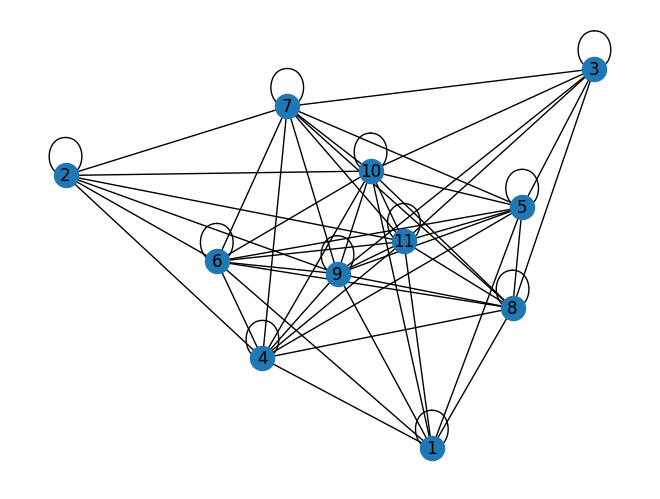

In [5]:
G = nx.from_numpy_array(Q)
nx.draw(G, with_labels=True, labels={i: i + 1 for i in G.nodes()})
plt.show()


Let's define a QUBO model and then solve it using DWaves code for complete enumeration and simulated annealing (eventually with Quantum annealiing too!).

In [6]:
model = dimod.BinaryQuadraticModel.from_qubo(Q, offset=Beta)
print(model)

BinaryQuadraticModel({0: -46.0, 1: -44.0, 2: -44.0, 3: -92.0, 4: -92.0, 5: -92.0, 6: -91.0, 7: -92.0, 8: -139.0, 9: -138.0, 10: -139.0}, {(3, 0): 96.0, (3, 1): 96.0, (4, 0): 96.0, (4, 2): 96.0, (4, 3): 96.0, (5, 0): 96.0, (5, 1): 96.0, (5, 3): 192.0, (5, 4): 96.0, (6, 1): 96.0, (6, 2): 96.0, (6, 3): 96.0, (6, 4): 96.0, (6, 5): 96.0, (7, 0): 96.0, (7, 2): 96.0, (7, 3): 96.0, (7, 4): 192.0, (7, 5): 96.0, (7, 6): 96.0, (8, 0): 96.0, (8, 1): 96.0, (8, 2): 96.0, (8, 3): 192.0, (8, 4): 192.0, (8, 5): 192.0, (8, 6): 192.0, (8, 7): 192.0, (9, 0): 96.0, (9, 1): 96.0, (9, 2): 96.0, (9, 3): 192.0, (9, 4): 192.0, (9, 5): 192.0, (9, 6): 192.0, (9, 7): 192.0, (9, 8): 288.0, (10, 0): 96.0, (10, 1): 96.0, (10, 2): 96.0, (10, 3): 192.0, (10, 4): 192.0, (10, 5): 192.0, (10, 6): 192.0, (10, 7): 192.0, (10, 8): 288.0, (10, 9): 288.0}, 144.0, 'BINARY')


Since the problem is relatively small (11 variables, $2^{11}=2048$ combinations), we can afford to enumerate all the solutions.

In [7]:
exactSampler = dimod.reference.samplers.ExactSolver()
exactSamples = exactSampler.sample(model)

In [8]:
# Some useful functions to get plots
def sample_label(sample):
    return ''.join(str(int(sample[i])) for i in sorted(sample))


def format_solution(sample, vartype):
    if vartype == dimod.BINARY:
        return sample_label(sample)
    return {i + 1: int(sample[i]) for i in sorted(sample)}


def best_samples(results):
    ordered = list(results.data(['sample', 'energy'], sorted_by='energy'))
    best_energy = ordered[0].energy
    best = [datum.sample for datum in ordered if np.isclose(datum.energy, best_energy)]
    return best, best_energy


def plot_enumerate(results, title=None):
    plt.figure()

    ordered = list(results.data(['sample', 'energy'], sorted_by='energy'))
    energies = [datum.energy for datum in ordered]
    samples = np.arange(len(energies))

    plt.bar(samples, energies)
    tick_step = max(1, len(samples) // 12)
    plt.xticks(samples[::tick_step])
    plt.xlabel('solution index (sorted by energy)')
    plt.ylabel('Energy')
    plt.title(str(title))
    plt.tight_layout()
    plt.show()
    print('minimum energy:', min(energies))


def report_best_solutions(results, model_name):
    best, best_energy = best_samples(results)
    print(f'Best {model_name} objective value: {best_energy}')
    print('Minimizing solution(s):', [format_solution(sample, results.vartype) for sample in best])


def plot_samples(results, title=None):
    plt.figure()
    if results.vartype == dimod.BINARY:
        samples = [sample_label(datum.sample) for datum in results.data(['sample'], sorted_by=None)]
        plt.xlabel('bitstring for solution')
    else:
        samples = np.arange(len(results))
        plt.xlabel('solution')

    counts = Counter(samples)
    total = len(samples)
    for key in counts:
        counts[key] /= total
    df = pd.DataFrame.from_dict(counts, orient='index').sort_index()
    df.plot(kind='bar', legend=None)

    plt.xticks(rotation=80)
    plt.ylabel('Probabilities')
    plt.title(str(title))
    plt.tight_layout()
    plt.show()


def plot_energies(results, title=None, skip=1):
    energies = results.data_vectors['energy']
    occurrences = results.data_vectors['num_occurrences']
    counts = {}
    total = sum(occurrences)
    for index, energy in enumerate(energies):
        counts[energy] = counts.get(energy, 0) + occurrences[index]
    for key in counts:
        counts[key] /= total
    df = pd.DataFrame.from_dict(counts, orient='index').sort_index()
    ax = df.plot(kind='bar', legend=None)

    plt.xlabel('Energy')
    plt.ylabel('Probabilities')
    ax.set_xticklabels([tick if not i % skip else '' for i, tick in enumerate(ax.get_xticklabels())])
    plt.title(str(title))
    plt.tight_layout()
    plt.show()
    print('minimum energy:', min(energies))


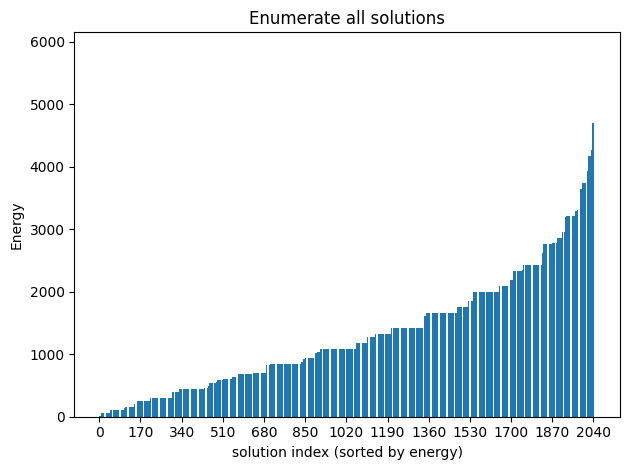

minimum energy: 5.0


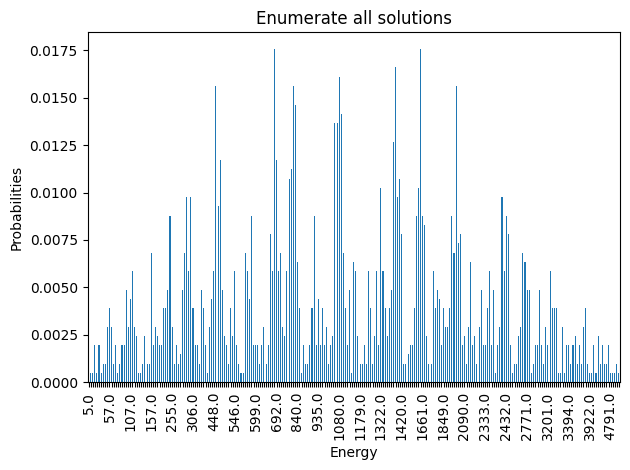

minimum energy: 5.0
Best QUBO objective value: 5.0
Minimizing solution(s): ['00000000001', '00000000100']


In [9]:
plot_enumerate(exactSamples, title='Enumerate all solutions')
plot_energies(exactSamples, title='Enumerate all solutions', skip=10)
report_best_solutions(exactSamples, 'QUBO')

Let's now solve this QUBO via traditional Integer Programming.

In [10]:
# We do not need to worry about the transformation to QUBO since dimod takes care of it.
Q, c = model.to_qubo()

# Define the model
model_pyo = pyo.ConcreteModel(name='QUBO example as an IP')

I = range(len(model))
J = range(len(model))
model_pyo.x = pyo.Var(I, domain=pyo.Binary)
model_pyo.y = pyo.Var(I, J, domain=pyo.Binary)

obj_expr = c

# Add model constraints
model_pyo.c1 = pyo.ConstraintList()
model_pyo.c2 = pyo.ConstraintList()
model_pyo.c3 = pyo.ConstraintList()
for (i, j) in Q.keys():
    if i != j:
        model_pyo.c1.add(model_pyo.y[i, j] >= model_pyo.x[i] + model_pyo.x[j] - 1)
        model_pyo.c2.add(model_pyo.y[i, j] <= model_pyo.x[i])
        model_pyo.c3.add(model_pyo.y[i, j] <= model_pyo.x[j])
        obj_expr += Q[i, j] * model_pyo.y[i, j]
    else:
        obj_expr += Q[i, j] * model_pyo.x[i]

model_pyo.objective = pyo.Objective(expr=obj_expr, sense=pyo.minimize)
print(f'Linearized QUBO IP with {len(I)} binary x variables and {len(I) * len(I)} auxiliary y variables.')


Linearized QUBO IP with 11 binary x variables and 121 auxiliary y variables.


We can solve the linearized QUBO reformulation with **[HiGHS](https://highs.dev/)**, an open-source MILP solver that is available both in the repo-managed Python environment and through the Colab setup cell above.


In [11]:
# The Colab setup cell installs HiGHS when needed.


In [12]:
# Define the HiGHS solver
opt_highs = Highs()
# We could also use another MILP solver, e.g. Gurobi or CPLEX, through Pyomo.


In [13]:
# Solve the reformulated QUBO with HiGHS
result_obj = opt_highs.solve(model_pyo)
qubo_ip_active = [i + 1 for i in I if pyo.value(model_pyo.x[i]) > 0.5]
print(f'Objective value: {pyo.value(model_pyo.objective):.1f}')
print(f'Active binary variables (1-based): {qubo_ip_active}')


Objective value: 5.0
Active binary variables (1-based): [11]


We observe that both the exact enumeration and the HiGHS reformulation attain the minimum QUBO objective value of $5$. In 1-based mathematical indexing, the two minimizing binary solutions have either $x_9 = 1$ or $x_{11} = 1$, with all other entries equal to $0$.
Python displays the raw sampler dictionaries with 0-based keys, so these same two solutions appear at indices `8` and `10` in the direct enumeration output.


## Ising model
This notebook will explain the basics of the Ising model. In order to implement the different Ising models we will use D-Wave's packages **[dimod](https://github.com/dwavesystems/dimod)** and **[neal](https://github.com/dwavesystems/dwave-neal)**, for defining the Ising model and solving it with simulated annealing, respectively. When posing the problems as integer programs, we will model using **[Pyomo](http://www.pyomo.org/)**, an open-source Python package that provides flexible access to different solvers and a general modeling framework for linear and nonlinear integer programs.
The integer-programming reformulation below converts the Ising model to an equivalent QUBO and then solves the resulting MILP with the open-source **[HiGHS](https://highs.dev/)** solver.


#### Problem statement
We pose the Ising problem as the following optimization problem:
$$
\min_{\sigma \in \{ -1,+1 \}^n} H(\sigma) =\min_{\sigma \in \{ -1,+1 \}^n} \sum_{(ij) \in E(G)} J_{ij}\sigma_i\sigma_j + \sum_{i \in V(G)}h_i\sigma_i + c_I
$$
where we optimize over spins $\sigma \in \{ -1,+1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{ij}$ and the linear coefficients are $h_i$. We also include an arbitrary offset of the Ising model $c_I$.

### Example

Suppose we have an Ising model defined from

$$
h = \begin{bmatrix}
145.0 \\ 122.0 \\ 122.0 \\ 266.0 \\ 266.0 \\ 266.0 \\ 242.5 \\ 266.0 \\ 386.5 \\ 387.0 \\ 386.5
\end{bmatrix},
J = \begin{bmatrix}
0 & 0 & 0 & 24 & 24 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 48 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
\end{bmatrix} \text{ and }
\beta = 1319.5
$$
Let's solve this problem

In [14]:
# These could also be simple lists and numpy matrices
h = {0: 145.0, 1: 122.0, 2: 122.0, 3: 266.0, 4: 266.0, 5: 266.0, 6: 242.5, 7: 266.0, 8: 386.5, 9: 387.0, 10: 386.5}
J = {(0, 3): 24.0, (0, 4): 24.0, (0, 5): 24.0, (0, 7): 24.0, (0, 8): 24.0, (0, 9): 24.0, (0, 10): 24.0, (1, 3): 24.0, (1, 5): 24.0, (1, 6): 24.0, (1, 8): 24.0, (1, 9): 24.0, (1, 10): 24.0, (2, 4): 24.0, (2, 6): 24.0, (2, 7): 24.0, (2, 8): 24.0, (2, 9): 24.0, (2, 10): 24.0, (3, 4): 24.0, (3, 5): 48.0, (3, 6): 24.0, (3, 7): 24.0, (3, 8): 48.0, (3, 9): 48.0, (3, 10): 48.0, (4, 5): 24.0, (4, 6): 24.0, (4, 7): 48.0, (4, 8): 48.0, (4, 9): 48.0, (4, 10): 48.0, (5, 6): 24.0, (5, 7): 24.0, (5, 8): 48.0, (5, 9): 48.0, (5, 10): 48.0, (6, 7): 24.0, (6, 8): 48.0, (6, 9): 48.0, (6, 10): 48.0, (7, 8): 48.0, (7, 9): 48.0, (7, 10): 48.0, (8, 9): 72.0, (8, 10): 72.0, (9, 10): 72.0}
cI = 1319.5

model_ising = dimod.BinaryQuadraticModel.from_ising(h, J, offset=cI)

Since the problem is relatively small (11 variables, $2^{11}=2048$ combinations), we can afford to enumerate all the solutions.

In [15]:
exactSamples = exactSampler.sample(model_ising)

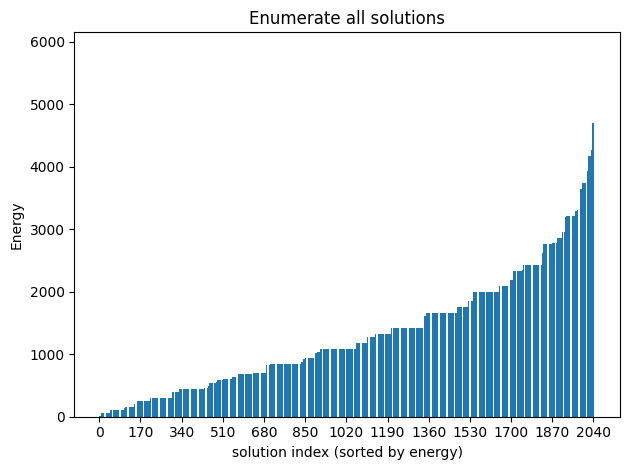

minimum energy: 5.0


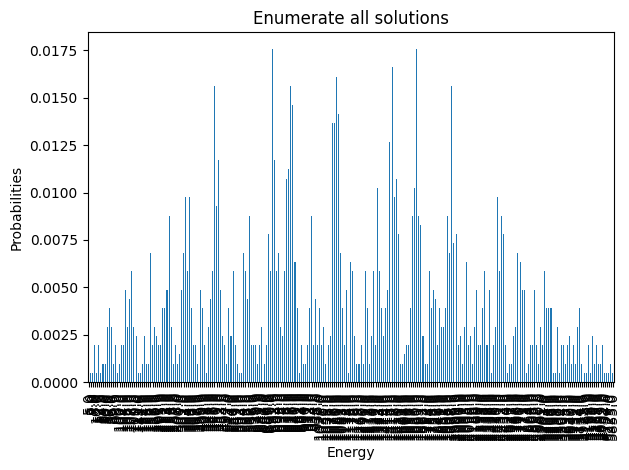

minimum energy: 5.0
Best Ising objective value: 5.0
Minimizing solution(s): [{1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}]


In [16]:
plot_enumerate(exactSamples, title='Enumerate all solutions')
plot_energies(exactSamples, title='Enumerate all solutions')
report_best_solutions(exactSamples, 'Ising')

Let's now solve this Ising Model via traditional Integer Programming.

In [17]:
# We do not need to worry about the transformation from Ising to QUBO since dimod takes care of it.
Q, c = model_ising.to_qubo()

# Define the model
model_ising_pyo = pyo.ConcreteModel(name='Ising example as an IP')

I = range(len(h))
J = range(len(h))
model_ising_pyo.x = pyo.Var(I, domain=pyo.Binary)
model_ising_pyo.y = pyo.Var(I, J, domain=pyo.Binary)

obj_expr = c

# Add model constraints
model_ising_pyo.c1 = pyo.ConstraintList()
model_ising_pyo.c2 = pyo.ConstraintList()
model_ising_pyo.c3 = pyo.ConstraintList()
for (i, j) in Q.keys():
    if i != j:
        model_ising_pyo.c1.add(model_ising_pyo.y[i, j] >= model_ising_pyo.x[i] + model_ising_pyo.x[j] - 1)
        model_ising_pyo.c2.add(model_ising_pyo.y[i, j] <= model_ising_pyo.x[i])
        model_ising_pyo.c3.add(model_ising_pyo.y[i, j] <= model_ising_pyo.x[j])
        obj_expr += Q[i, j] * model_ising_pyo.y[i, j]
    else:
        obj_expr += Q[i, j] * model_ising_pyo.x[i]

model_ising_pyo.objective = pyo.Objective(expr=obj_expr, sense=pyo.minimize)
print(f'Binary reformulation of the Ising model with {len(I)} x variables and {len(I) * len(I)} auxiliary y variables.')


Binary reformulation of the Ising model with 11 x variables and 121 auxiliary y variables.


In [18]:
# Solve the reformulated Ising model with HiGHS
result_obj = opt_highs.solve(model_ising_pyo)
ising_ip_active = [i + 1 for i in I if pyo.value(model_ising_pyo.x[i]) > 0.5]
print(f'Objective value: {pyo.value(model_ising_pyo.objective):.1f}')
print(f'Active binary variables (1-based): {ising_ip_active}')


Objective value: 5.0
Active binary variables (1-based): [11]


Both the exact enumeration and the HiGHS reformulation attain the minimum Ising objective value of $5$. In spin variables, the two minimizing states have either $s_9 = 1$ or $s_{11} = 1$, with all other spins equal to $-1$.
After converting the Ising model to the binary QUBO form for the MILP solve, those same minima appear as $x_9 = 1$ or $x_{11} = 1$, with all other binary variables equal to $0$.


## Let's go back to the slides

We can also solve this problem using Simulated Annealing

In [19]:
simAnnSampler = neal.SimulatedAnnealingSampler()
simAnnSamples = simAnnSampler.sample(model_ising, num_reads=1000)

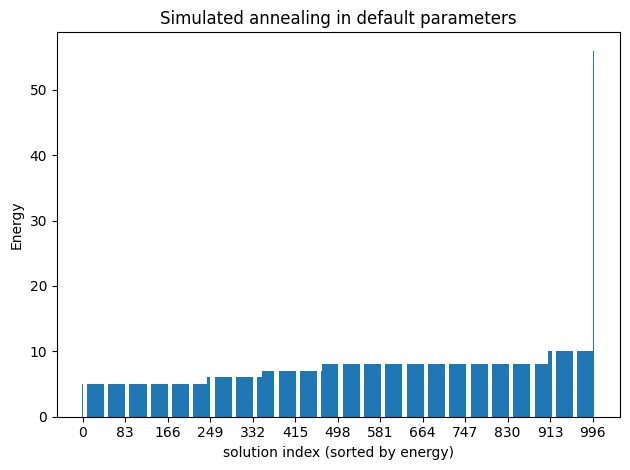

minimum energy: 5.0


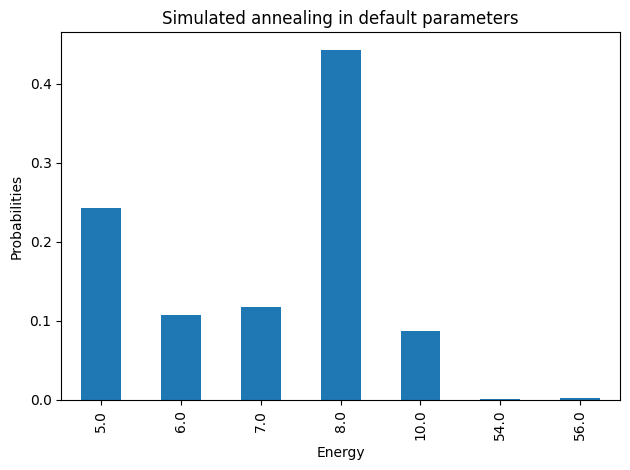

minimum energy: 5.0
Best Ising objective value: 5.0
Minimizing solution(s): [{1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: 1, 10: -1, 11: -1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 7: -1, 8: -1, 9: -1, 10: -1, 11: 1}, {1: -1, 2: -1, 3: -1, 4: -1, 5: -1, 6: -1, 

In [20]:
plot_enumerate(simAnnSamples, title='Simulated annealing in default parameters')
plot_energies(simAnnSamples, title='Simulated annealing in default parameters')
report_best_solutions(simAnnSamples, 'Ising')

In [21]:
simAnnSamples.info

{'beta_range': [np.float64(0.00041111932417553103),
  np.float64(0.1458971970580513)],
 'beta_schedule_type': 'geometric',
 'timing': {'preprocessing_ns': 1967357,
  'sampling_ns': 170743527,
  'postprocessing_ns': 407099}}

## Let's go back to the slides

Let's solve the graph coloring problem in the slides using QUBO.

#### Vertex $k$-coloring of graphs

Given a graph $G(V, E)$, where $V$ is the set of vertices and $E$ is the set of edges of $G$, and a positive integer $k$, we ask if it is possible to assign a color to every vertex from $V$, such that adjacent vertices have different colors assigned.

$G(V, E)$ has $12$ vertices and $23$ edges.
We ask if the graph is $3$–colorable.
Let’s first encode $V$ and $E$ using Julia’s built–in data structures:

**Note:** This tutorial is heavily inspired by D-Wave's Map coloring of Canada example found **[here](https://docs.ocean.dwavesys.com/en/stable/examples/map_coloring.html)**.


In [22]:
import dwavebinarycsp


/tmp/ipykernel_1148694/4003106872.py:1: DeprecationWarning: dwavebinarycsp is deprecated and will be removed in Ocean 10. For solving problems with constraints, we recommend using the hybrid solvers in the Leap service. You can find documentation for the hybrid solvers at https://docs.ocean.dwavesys.com.
  import dwavebinarycsp


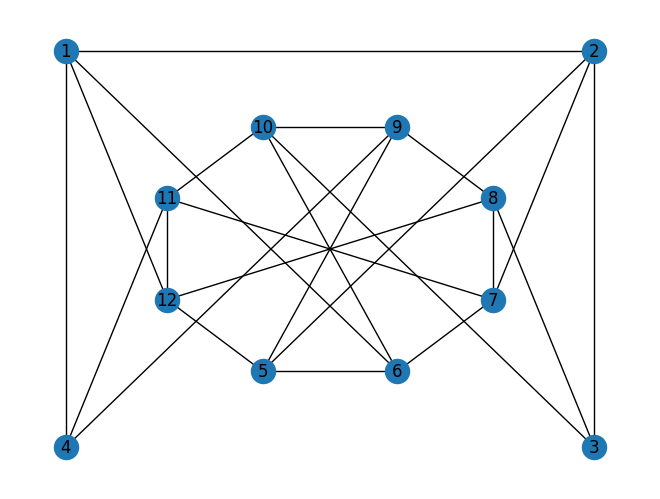

In [23]:
V = range(1, 12+1)
E = [(1,2),(2,3),(1,4),(1,6),(1,12),(2,5),(2,7),(3,8),(3,10),(4,11),(4,9),(5,6),(6,7),(7,8),(8,9),(9,10),(10,11),(11,12),(5,12),(5,9),(6,10),(7,11),(8,12)]
layout = {i: [np.cos((2*i+1)*np.pi/8),np.sin((2*i+1)*np.pi/8)] for i in np.arange(5,13)}
layout[1] = [-1.5,1.5]
layout[2] = [1.5,1.5]
layout[3] = [1.5,-1.5]
layout[4] = [-1.5,-1.5]
G = nx.Graph()
G.add_edges_from(E)
nx.draw(G, with_labels=True, pos=layout)

In [24]:
# Function for the constraint that two nodes with a shared edge not both select
# one color
def not_both_1(v, u):
    return not (v and u)

# Valid configurations for the constraint that each node select a single color, in this case we want to use 3 colors
one_color_configurations = {(0, 0, 1), (0, 1, 0), (1, 0, 0)}
colors = len(one_color_configurations)

# Create a binary constraint satisfaction problem
csp = dwavebinarycsp.ConstraintSatisfactionProblem(dwavebinarycsp.BINARY)

# Add constraint that each node select a single color
for node in V:
    variables = ['x'+str(node)+','+str(i) for i in range(colors)]
    csp.add_constraint(one_color_configurations, variables)

# Add constraint that each pair of nodes with a shared edge not both select one color
for edge in E:
    v, u = edge
    for i in range(colors):
        variables = ['x'+str(v)+','+str(i), 'x'+str(u)+','+str(i)]
        csp.add_constraint(not_both_1, variables)

Defining the Binary Quadratic Model (QUBO) using the CSP library we have:


In [25]:
bqm = dwavebinarycsp.stitch(csp)
simAnnSamples = simAnnSampler.sample(bqm, num_reads=1000)

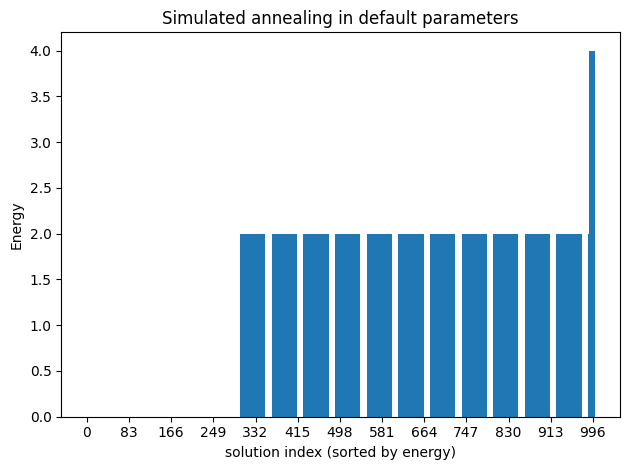

minimum energy: 0.0


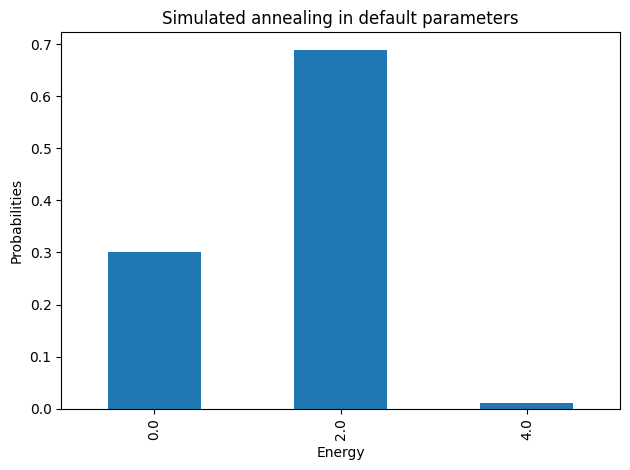

minimum energy: 0.0


In [26]:
plot_enumerate(simAnnSamples, title='Simulated annealing in default parameters')
plot_energies(simAnnSamples, title='Simulated annealing in default parameters')

Because of precision issues in the translation to a BQM, we *may* obtain very tiny coefficients that should be zero. In any case, since this is a constraint satisfaction problem, any of the solutions with energy ~0 is a valid coloring.


In [27]:
# Check that a good solution was found
sample = simAnnSamples.first.sample     # doctest: +SKIP
if not csp.check(sample):           # doctest: +SKIP
        print("Failed to color map. Try sampling again.")
else:
        print(sample)

{'x1,0': np.int8(0), 'x1,1': np.int8(1), 'x1,2': np.int8(0), 'x10,0': np.int8(0), 'x10,1': np.int8(1), 'x10,2': np.int8(0), 'x11,0': np.int8(1), 'x11,1': np.int8(0), 'x11,2': np.int8(0), 'x12,0': np.int8(0), 'x12,1': np.int8(0), 'x12,2': np.int8(1), 'x2,0': np.int8(1), 'x2,1': np.int8(0), 'x2,2': np.int8(0), 'x3,0': np.int8(0), 'x3,1': np.int8(0), 'x3,2': np.int8(1), 'x4,0': np.int8(0), 'x4,1': np.int8(0), 'x4,2': np.int8(1), 'x5,0': np.int8(0), 'x5,1': np.int8(1), 'x5,2': np.int8(0), 'x6,0': np.int8(1), 'x6,1': np.int8(0), 'x6,2': np.int8(0), 'x7,0': np.int8(0), 'x7,1': np.int8(0), 'x7,2': np.int8(1), 'x8,0': np.int8(0), 'x8,1': np.int8(1), 'x8,2': np.int8(0), 'x9,0': np.int8(1), 'x9,1': np.int8(0), 'x9,2': np.int8(0)}


In [28]:
# Function that plots a returned sample
def plot_map(sample):
    # Translate from binary to integer color representation
    color_map = {}
    for node in V:
          for i in range(colors):
            if sample['x'+str(node)+','+str(i)]:
                color_map[node] = i
    # Plot the sample with color-coded nodes
    node_colors = [color_map.get(node) for node in G.nodes()]
    nx.draw(G, with_labels=True, pos=layout, node_color=node_colors)
    plt.show()

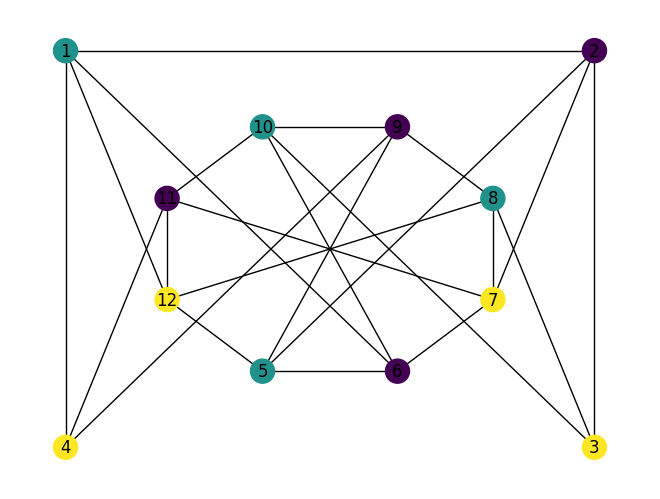

In [29]:
plot_map(sample)